# TASK - 3: Sales Prediction using Python

Author: ZUNAIRA FATIMA

Batch: JUNE C4-26

Domain: Data Science

#AIM :
*To develop a machine learning model using Python that predicts product sales based on factors such as advertising expenditure and other relevant features, helping businesses forecast future sales and make better decisions.*

## The project is divided into three phases:

*   Data Preprocessing,
*   Data Analytics (EDA),
*   and Model Building.

*Through these phases, the data is cleaned, analyzed, and used to train a predictive model that identifies the key factors affecting flower species and provides accurate classification predictions.*

In [2]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


**Phase 1: Data Preprocessing**

In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Loading the Dataset
data = pd.read_csv('advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [5]:
# Display Dataset
print("First 5 Rows:")
data.head()

First 5 Rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [28]:
# Dataset Information
print("Shape of Dataset:", data.shape)

Shape of Dataset: (200, 4)


In [27]:
print("Dataset Information:")
data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [26]:
print("Statistical Summary:")
print(data.describe())

Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [25]:
# Display column names
print("Column Names:")
data.columns

Column Names:


Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [24]:
# Checking the missing values
print("Missing Values:")
data.isnull().sum()

Missing Values:


,0
TV,0
Radio,0
Newspaper,0
Sales,0


**Now we'll check the Data types of our columns**

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


After checking the data types, we can see that all columns have numerical values. The dataset contains only float data types, making it ready for machine learning operations.

In [13]:
#Displaying the first few rows of the processed dataset to verify that data cleaning and preprocessing have been completed successfully.
data.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


**We have completed our first phase, which is Data Preprocessing. The dataset is now cleaned, transformed, and ready for data analysis and model building.**

**Phase 2: Data Analytics (EDA)**

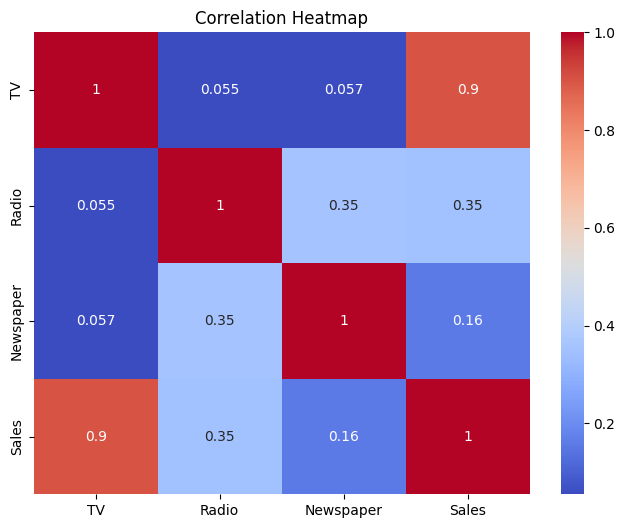

In [14]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Insight:**

* **TV and Sales** have a **strong positive correlation (0.90)**, making TV the most effective advertising channel.

* **Radio and Sales** show a **moderate positive correlation (0.35)**.

* **Newspaper and Sales** have a **weak correlation (0.16)**, indicating a low impact on sales.

* Overall, **TV advertising contributes the most to increasing sales**, while **newspaper advertising has the least influence**.

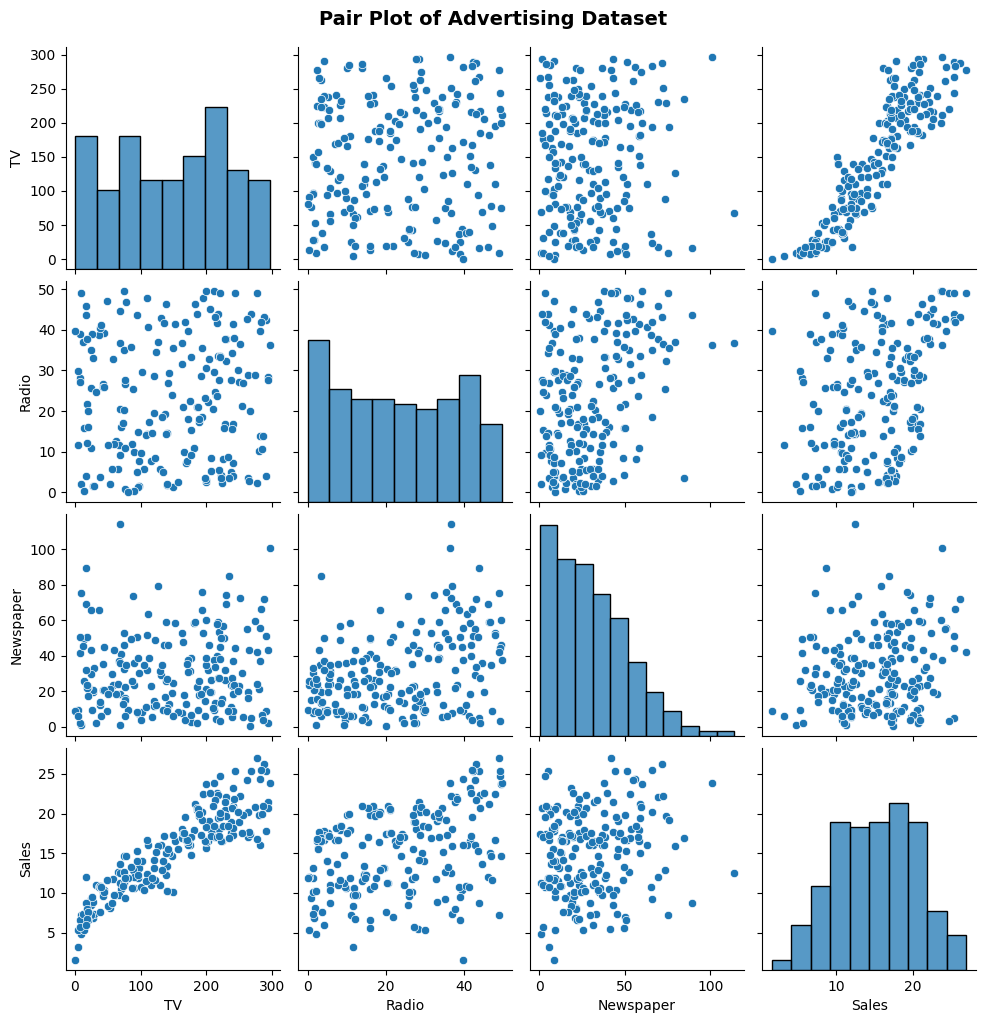

In [15]:
#Pairplot of Advertising Dataset
sns.pairplot(data)
plt.suptitle("Pair Plot of Advertising Dataset", y=1.02, fontsize=14, weight='bold')
plt.show()


**Insight:**

* The pair plot shows a **strong positive relationship between TV advertising and Sales**, indicating that higher TV advertising leads to higher sales.

* **Radio** has a **moderate positive relationship** with Sales.

* **Newspaper** shows a **weak relationship** with Sales, suggesting it has less impact.

* The diagonal histograms indicate that the features are **reasonably well distributed** with no major outliers.

**Overall Conclusion: TV advertising has the strongest influence on sales, followed by Radio, while Newspaper contributes the least.**

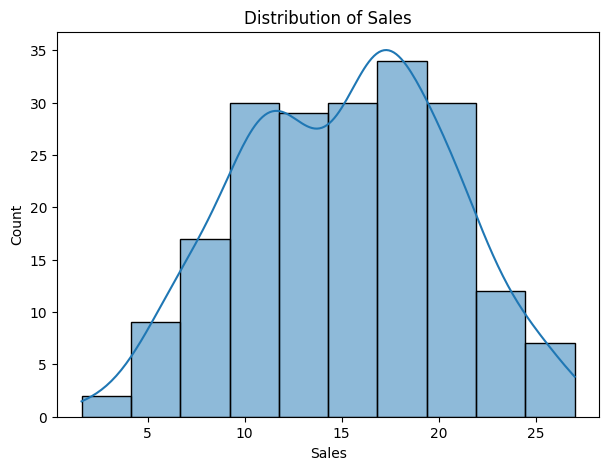

In [16]:
# Distribution of Sales
plt.figure(figsize=(7,5))
sns.histplot(data['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.show()

**Insight:**

* The sales distribution is **approximately normal (bell-shaped)**.

* Most sales values are concentrated between **10 and 20**.

* There are **no significant outliers**, indicating a well-balanced dataset.

* The target variable is **evenly distributed**, making it suitable for machine learning modeling.

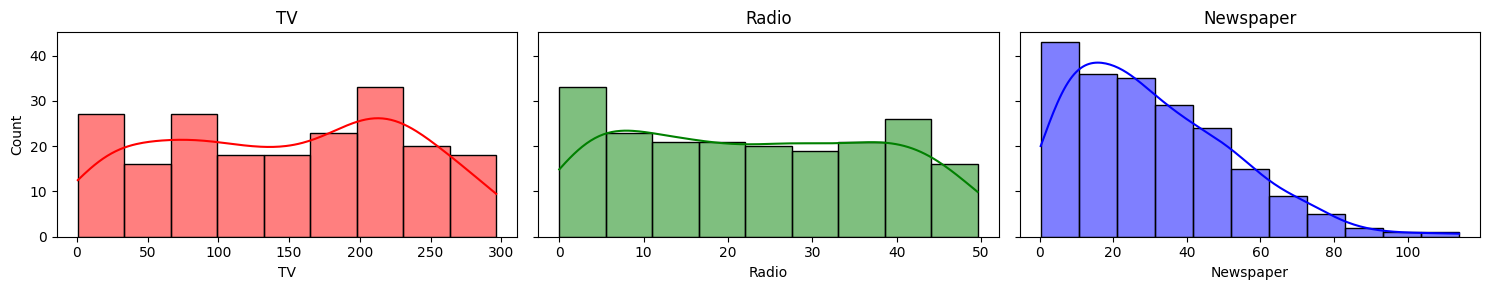

In [17]:
fig,axs = plt.subplots(1,3, sharey=True, figsize=(15,3))

sns.histplot(data['TV'], ax=axs[0], color='red', kde=True)
axs[0].set_title('TV')

sns.histplot(data['Radio'], ax=axs[1], color='green', kde=True)
axs[1].set_title('Radio')

sns.histplot(data['Newspaper'], ax=axs[2], color='blue', kde=True)
axs[2].set_title('Newspaper')

plt.tight_layout()
plt.show()

**Insight:**

* **TV advertising** is fairly evenly distributed across different spending levels.

* **Radio advertising** also shows a balanced distribution with no major skewness.

* **Newspaper advertising** is **right-skewed**, with most values concentrated at lower spending levels and fewer high-spending observations.

* Overall, **TV and Radio are more uniformly distributed**, while **Newspaper has a positively skewed distribution**.

**Phase: 3 Building a ML model**

**Before proceeding to the model building phase, the dataset is checked once again to ensure that all columns have the correct data types, contain no missing values, and are ready for machine learning operations.**

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [19]:
#Importing necessary Library for ml operations
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Separate features (X) and target variable (y)
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

In [21]:
#Split Dataset into Training & Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
#Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [30]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475  8.92396497  8.4817344
 18.2075123   8.06750728 12.64550975 14.93162809  8.12814594 17.89876565
 11.00880637 20.47832788 20.80631846 12.59883297 10.9051829  22.38854775
  9.41796094  7.92506736 20.83908497 13.81520938 10.77080925  7.92682509
 15.95947357 10.63490851 20.80292008 10.43434164 21.5784752  21.18364487
 12.12821771 22.80953262 12.60992766  6.46441252]


# **The model has successfully generated predicted sales values for the test dataset.The predicted values range approximately from 6.46 to 23.72, which is consistent with the actual sales range.**

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

print("\nModel Accuracy:", round(r2*100,2), "%")

Model Evaluation
Mean Absolute Error (MAE): 1.2748262109549338
Mean Squared Error (MSE): 2.9077569102710896
R2 Score: 0.9059011844150826

Model Accuracy: 90.59 %


**Insight:**

* The model achieved an **R² Score of 0.9059 (90.59%)**, indicating that it explains about **90.6% of the variation in sales**.

* The **Mean Absolute Error (MAE) of 1.27** shows that the predictions differ from the actual sales by about **1.27 units on average**.

* The **Mean Squared Error (MSE) of 2.91** is low, indicating that prediction errors are minimal.

* **Overall, the Linear Regression model performs well and provides accurate sales predictions with 90.59% accuracy**.

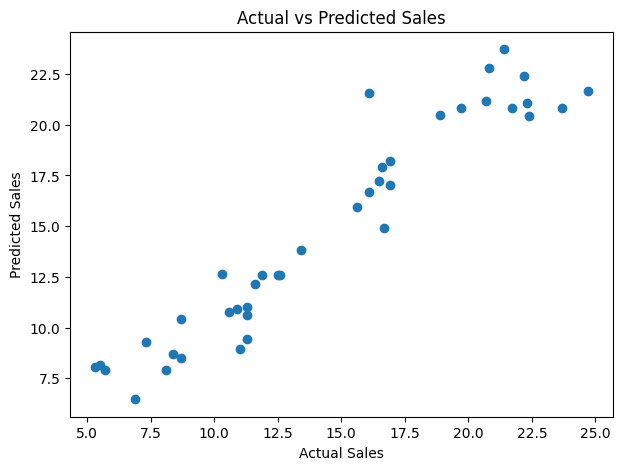

In [33]:
#Actual vs Predicted Visualization
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

**Insight:**

The Actual vs Predicted Sales plot shows a **strong positive correlation**, indicating that the model predicts sales with **high accuracy**. Most points are closely aligned, suggesting minimal prediction error and good model performance

In [35]:
#Compare Actual and Predicted Values
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print("Comparison Table:")
comparison.head(10)

Comparison Table:


,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


**The comparison table indicates that the predicted sales values are closely aligned with the actual sales values, demonstrating good model accuracy and reliable prediction performance**

# **Conclusion:**

# **The Linear Regression model successfully predicts sales based on advertising expenditure. The model achieved a good R² score, indicating strong prediction performance. The analysis shows that advertising platforms such as TV, Radio, and Newspaper significantly influence sales. This project demonstrates how machine learning techniques can be used to forecast sales and help businesses make data-driven decisions.**